In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("run_results.csv")

In [3]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time,rng_seed
count,2012.000000,2012.0,2012.000000,2012.000000,2012.000000,2012.0,2.012000e+03,2.012000e+03,2.012000e+03,2.012000e+03,...,2.012000e+03,2012.000000,2.012000e+03,2.012000e+03,2012.000000,2.012000e+03,2012.000000,2012.000000,2012.000000,2012.000000
mean,279.204771,24.0,83.069583,4.326044,1116.819085,32128.0,8.970291e+06,8.970291e+06,8.970291e+06,1.421299e+05,...,1.939702e-04,0.027212,1.939702e-04,4.849255e-05,0.027212,1.939702e-04,6.025915,5.198399,21098.951784,1.502982
std,253.389984,0.0,44.048808,5.326352,1013.559937,0.0,8.140913e+06,8.140913e+06,8.140913e+06,2.562973e+05,...,3.555890e-04,0.038445,3.555890e-04,8.889726e-05,0.038445,3.555890e-04,20.416911,18.312317,31635.759844,7.803625
min,32.000000,24.0,32.000000,1.000000,128.000000,32128.0,1.028096e+06,1.028096e+06,1.028096e+06,1.024000e+03,...,9.536743e-07,0.000977,9.536743e-07,2.384186e-07,0.000977,9.536743e-07,2.975324,2.975324,114.124368,0.000000
25%,128.000000,24.0,32.000000,1.000000,512.000000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,1.779982e-05,0.003906,1.779982e-05,4.449955e-06,0.003906,1.779982e-05,3.509579,3.509464,834.076802,0.000000
50%,128.000000,24.0,64.000000,2.000000,512.000000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,5.651091e-05,0.012402,5.651091e-05,1.412773e-05,0.012402,5.651091e-05,4.202549,4.109644,10446.997124,0.000000
75%,512.000000,24.0,128.000000,4.000000,2048.000000,32128.0,1.644954e+07,1.644954e+07,1.644954e+07,2.621440e+05,...,1.937745e-04,0.033281,1.937745e-04,4.844364e-05,0.033281,1.937745e-04,5.190997,4.750368,26910.915238,0.000000
max,1024.000000,24.0,128.000000,32.000000,4096.000000,32128.0,3.289907e+07,3.289907e+07,3.289907e+07,1.048576e+06,...,2.278377e-03,0.250000,2.278377e-03,5.695943e-04,0.250000,2.278377e-03,374.245812,374.018747,169222.904452,42.000000


In [4]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_step', 'n_warmup_step',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time',
       'lr_schedule_mode', 'rng_seed'],
      dtype='object')


In [5]:
df = df[df['head_dimension'] == 32]

In [6]:
print(df['n_pretrain_step'].unique())
print(df['n_training_tokens'].unique())
print(df['n_parameters'].unique())
print(df['lr_schedule_mode'].unique())

[  696.  1526. 89208.  3591.  9342. 27324.]
[4.55628800e+07 9.99731200e+07 5.84630272e+09 2.35335680e+08
 6.12229120e+08 1.79068928e+09]
[  2278144   4998656  11766784  30611456  89534464 292315136]
['relative' 'clipping']


In [7]:
# calculate effective learning rate (base_lr * sqrt(n_training_tokens))
df['effective_lr'] = df['base_lr'] * np.sqrt(df['n_training_tokens'])

In [8]:
# create column that states whether model was trained to full length or not
df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

# split into relative and not relative df
df_relative = df[df['lr_schedule_mode'] == 'relative']
df_not_relative = df[df['lr_schedule_mode'] != "relative"]

# take best runs for each learning rate (different initialization variances)
df_best_runs_not_relative = (
    df_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["init_stddev", "d_model", "full_length_training"], keep="first")
)
df_best_runs_relative = (
    df_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["init_stddev", "d_model", "full_length_training"], keep="first")
)

# take optimal lr for optimum plotting
df_optimal_inits_not_relative = (
    df_best_runs_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)
df_optimal_inits_relative = (
    df_best_runs_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)

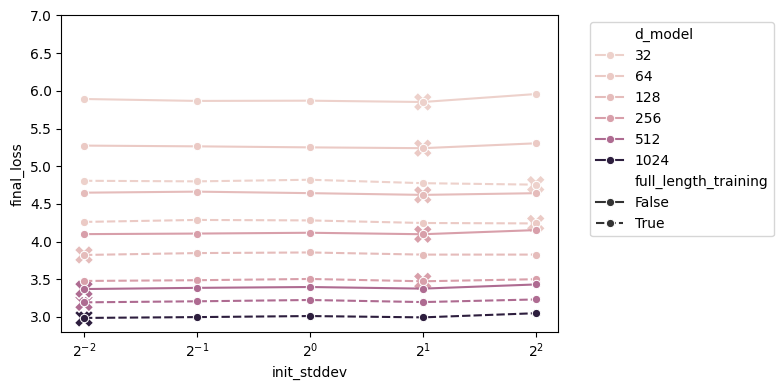

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# final loss
sns.lineplot(df_best_runs_not_relative,
    x="init_stddev",
    y="final_loss",
    hue='d_model',
    style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_inits_not_relative,
    x='init_stddev',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

ax.set_xscale('log', base=2)
# ax.set_xlim(2**-10, 2**-3)
ax.set_ylim(2.8, 7)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

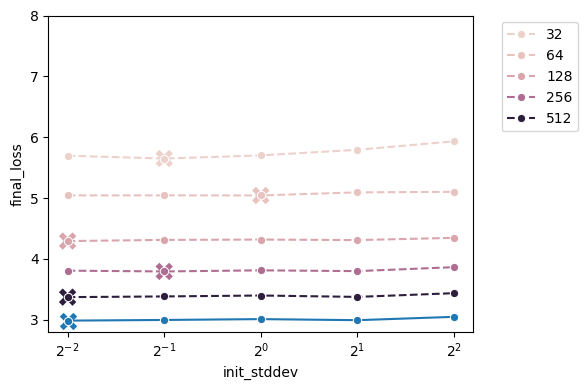

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# final loss
sns.lineplot(df_best_runs_not_relative.query("d_model == 1024"),
    x="init_stddev",
    y="final_loss",
    # hue='d_model',
    # style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_inits_not_relative.query("d_model == 1024"),
    x='init_stddev',
    y='final_loss',
    # hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

# relative shorter trainings
sns.lineplot(df_best_runs_relative,
    x="init_stddev",
    y="final_loss",
    hue='d_model',
    # style='full_length_training',
    ax=ax,
    linestyle='--',
    marker='o',
    )

sns.scatterplot(
    df_optimal_inits_relative,
    x='init_stddev',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)


ax.set_xscale('log', base=2)
# ax.set_xlim(2**-10, 2**-3)
ax.set_ylim(2.8, 8)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
print(df_optimal_inits_not_relative.value_counts('init_stddev'))

init_stddev
2.00    5
0.25    4
4.00    2
Name: count, dtype: int64


In [24]:
# 1. Filter for your specific model size
df_1024_only = df_not_relative[df_not_relative["d_model"] == 1024]

# 2. Sort by loss and drop duplicates to isolate the best init_stddev per base_lr
df_best_inits_per_lr = (
    df_1024_only
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "full_length_training"], keep="first")
)

# 3. Print a clean view of the results
results_view = df_best_inits_per_lr[["base_lr", "init_stddev", "final_loss", "full_length_training"]]
print(results_view.sort_values(by=["full_length_training", "base_lr"]))

       base_lr  init_stddev  final_loss  full_length_training
1984  0.000977         0.25    3.149801                  True
2000  0.001674         0.25    3.064461                  True
1979  0.002871         0.25    3.015940                  True
1972  0.004922         0.25    2.991492                  True
1989  0.008438         0.25    2.986538                  True
1992  0.014467         0.25    3.000108                  True
1997  0.024803         0.50    3.046641                  True
